# Trend figures on the coherent GGI

Regenerates the gender-gap trend figures from `analysis/technical_report/trend.qmd` using the
**coherent** GGI (`{ind}_ggi_coherent_parity`, derived female/male) in place of the directly
predicted `{ind}_fm_ratio`.

Country classifications, thresholds and the figure set are preserved from the `.qmd` — only the
measure changes, so the figures are comparable to the originals.

**Three deliberate differences from the `.qmd`:**

1. **No uncertainty ribbons.** `predicted_error` is not propagated to the coherent GGI (D16): a
   ratio's variance is not the ratio of variances, and the underlying error model is
   near-degenerate. The originals shaded `pred ± predicted_error`; that band has no coherent
   counterpart, so it is omitted rather than faked.
2. **The final year is partial and labelled as such.** The series now reaches 2026, but that year
   is not yet complete, so its annual mean averages fewer months than a full year. It is plotted and
   its month count is shown on the axis; the `total_gain` thresholds stay anchored to the last
   complete year so country classifications remain comparable to the originals. Both update
   automatically as more months arrive.
3. **Many-country figures highlight rather than cycle.** Some filters select 20–40 countries. Giving
   each its own hue means cycling an 8-colour palette 5 times — unreadable, and the resulting colours
   are not identity-bearing. Those figures draw all selected countries in recessive grey and
   direct-label the eight largest movers.

In [1]:
import _bootstrap  # noqa: F401  — puts src/ on sys.path
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import params

warnings.filterwarnings('ignore')

STYLE = params.STYLE
PALETTE = STYLE['colors']          # validated assignment order, see params.plot_color_order
INK, MUTED, GRID = '#222222', '#666666', '#d9d9d9'

TREND_START = 2015
FIGDIR = params.fig_dir('coherent_ggi') / 'coherent_ggi'
FIGDIR.mkdir(parents=True, exist_ok=True)
print('figures ->', FIGDIR.relative_to(params.ROOT))

figures -> outputs/fig/coherent_ggi


## Load

Reads the country-year table produced by `src/13_coherent_ggi.py`. `mean_of_ratios` is the annual
aggregation the trend figures have always used; `ratio_of_means` agrees to within 0.001 (D16).

In [2]:
def latest_table(stem):
    """most recent date-stamped build of a table from src/13_coherent_ggi.py"""
    matches = sorted(params.table_dir('coherent_ggi').glob(f'{stem}_*.csv'))
    if not matches:
        raise FileNotFoundError(f'no {stem}_*.csv — run src/13_coherent_ggi.py first')
    return pd.read_csv(matches[-1])


annual = latest_table('coherent_ggi_country_year')

# How many months each year contributes. Pre-2019 the pipeline published one annual figure per
# year; from 2019 it is monthly, so a recent year with fewer than 12 months is still filling up.
months_per_year = (latest_table('coherent_ggi_analytical')
                   .groupby('year')['month'].nunique())

TREND_END = int(months_per_year.index.max())
FINAL_YEAR_MONTHS = int(months_per_year.loc[TREND_END])
FINAL_YEAR_PARTIAL = TREND_END >= 2019 and FINAL_YEAR_MONTHS < 12

# thresholds stay on the last complete year, so classifications do not shift as months trickle in
GAIN_END = TREND_END - 1 if FINAL_YEAR_PARTIAL else TREND_END

annual = annual[annual['year'].between(TREND_START, TREND_END)].copy()

print(f'window {TREND_START}-{TREND_END}'
      + (f'  ({TREND_END} is partial: {FINAL_YEAR_MONTHS} months)' if FINAL_YEAR_PARTIAL else '')
      + f'  |  total_gain measured {TREND_START}->{GAIN_END}')

# region2: World Bank region, with Sub-Saharan Africa split into subregions (preserved from trend.qmd)
iso_to_sub = {iso: sub for sub, isos in params.ssa_subregions.items() for iso in isos}
annual['subregion'] = annual['gid_0'].map(iso_to_sub).fillna('Other')
annual['region2'] = np.where(annual['region'] == 'Sub-Saharan Africa',
                             annual['subregion'], annual['region'])

print(f"{annual['gid_0'].nunique()} countries, {annual['year'].min()}-{annual['year'].max()}")
annual[['gid_0', 'country', 'region2', 'year',
        'internet_ggi_coherent_mean_of_ratios', 'internet_ggi_direct']].head()

window 2015-2026  (2026 is partial: 5 months)  |  total_gain measured 2015->2025
211 countries, 2015-2026


,gid_0,country,region2,year,internet_ggi_coherent_mean_of_ratios,internet_ggi_direct
0,ABW,Aruba,Latin America & Caribbean,2015,0.956798,0.935000
1,ABW,Aruba,Latin America & Caribbean,2016,0.962825,0.947000
2,ABW,Aruba,Latin America & Caribbean,2017,0.963680,0.956000
3,ABW,Aruba,Latin America & Caribbean,2018,0.966981,0.968000
4,ABW,Aruba,Latin America & Caribbean,2019,0.970641,0.974333


## Derived measures

`total_gain`, `mean_pred` and `proportional_gain` keep the definitions from `trend.qmd`, evaluated
on whichever measure is passed in — so the same code produces the coherent figures and the direct
comparisons.

In [3]:
def country_panel(df, value_col):
    """country x year matrix of one measure, plus the summaries the figure filters use"""
    wide = df.pivot_table(index='gid_0', columns='year', values=value_col)
    summary = pd.DataFrame({
        'total_gain': wide[GAIN_END] - wide[TREND_START],
        'mean_pred': wide.mean(axis=1),
    })
    summary['proportional_gain'] = summary['total_gain'] / wide[TREND_START]
    names = df.drop_duplicates('gid_0').set_index('gid_0')
    summary['country'] = names['country']
    summary['region2'] = names['region2']
    return wide, summary


def measure(indicator, kind='coherent'):
    return (f'{indicator}_ggi_coherent_mean_of_ratios' if kind == 'coherent'
            else f'{indicator}_ggi_direct')

## Plotting

One helper for every figure. Identity is never carried by colour alone — every highlighted series is
direct-labelled at its right-hand end, which is also the relief the palette's sub-3:1 contrast
against the surface requires.

In [4]:
def spread_labels(ends, min_gap):
    """
    push labels apart so none overprints its neighbour

    Walks the end points bottom-up, lifting any that sits closer than `min_gap` to the one below,
    then recentres so the block stays near its original position.
    """
    ordered = sorted(ends, key=lambda k: ends[k][0])
    placed, previous = {}, -np.inf
    for iso in ordered:
        y = max(ends[iso][0], previous + min_gap)
        placed[iso] = y
        previous = y

    shift = (np.mean([ends[i][0] for i in ordered]) - np.mean(list(placed.values())))
    return {iso: y + shift for iso, y in placed.items()}

In [5]:
def trend_plot(wide, summary, countries, title, filename, highlight=8, ylabel='Coherent GGI'):
    """
    country trend lines, highlighting the largest movers

    Up to `highlight` countries get a palette colour and a direct label; any others are drawn in
    recessive grey for context. Cycling the palette past its eight slots would make colour
    meaningless, so beyond that the greys carry the distribution and the labels carry identity.
    """
    if len(countries) == 0:
        print(f'  [skip] {filename}: no countries meet the criteria')
        return None

    ranked = summary.loc[countries, 'total_gain'].abs().sort_values(ascending=False)
    focus = list(ranked.index[:highlight])
    context = [c for c in countries if c not in focus]

    fig, ax = plt.subplots(figsize=STYLE['figsize'])
    years = wide.columns.tolist()

    for iso in context:
        ax.plot(years, wide.loc[iso], color=GRID, linewidth=1, zorder=1)

    ends = {}
    for i, iso in enumerate(focus):
        series = wide.loc[iso]
        colour = PALETTE[i % len(PALETTE)]
        ax.plot(years, series, color=colour, linewidth=2, zorder=3)
        ax.plot(years[-1], series.iloc[-1], 'o', color=colour, markersize=6, zorder=4)
        ends[iso] = (series.iloc[-1], colour)

    # countries that finish close together would overprint their labels, so nudge them apart
    # vertically and draw a leader line back to the true end point
    span = np.nanmax(wide.values) - np.nanmin(wide.values)
    for iso, y_label in spread_labels(ends, min_gap=span * 0.045).items():
        y_true, colour = ends[iso]
        if abs(y_label - y_true) > 1e-9:
            ax.plot([years[-1], years[-1] + 0.35], [y_true, y_label],
                    color=colour, linewidth=0.8, alpha=0.6, zorder=2)
        ax.annotate(f'  {summary.loc[iso, "country"]}', (years[-1] + 0.35, y_label),
                    color=INK, fontsize=STYLE['tick_fs'], va='center', zorder=5)

    ax.set_title(title, fontsize=STYLE['title_fs'], color=INK, loc='left', fontweight='bold')
    ax.set_xlabel('Year', fontsize=STYLE['label_fs'], color=MUTED)
    ax.set_ylabel(ylabel, fontsize=STYLE['label_fs'], color=MUTED)
    ax.tick_params(labelsize=STYLE['tick_fs'], colors=MUTED)
    ax.grid(axis='y', color=GRID, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(GRID)
    # the extra width on the right is a label gutter, not plot area — keep ticks on data years only
    ax.set_xlim(TREND_START, TREND_END + 3.2)
    ticks = list(range(TREND_START, TREND_END + 1, 2))
    if TREND_END not in ticks:
        ticks.append(TREND_END)
    ax.set_xticks(ticks)
    if FINAL_YEAR_PARTIAL:
        ax.set_xticklabels([f'{y}*' if y == TREND_END else str(y) for y in ticks])
        ax.text(1.0, -0.13, f'* {TREND_END} covers {FINAL_YEAR_MONTHS} months',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=STYLE['tick_fs'] - 1, color=MUTED)

    if context:
        ax.plot([], [], color=GRID, linewidth=1,
                label=f'{len(context)} further countries meeting the criteria')
        ax.legend(frameon=False, fontsize=STYLE['tick_fs'], loc='lower right', labelcolor=MUTED)

    fig.tight_layout()
    path = FIGDIR / filename
    fig.savefig(path, dpi=STYLE['dpi'], bbox_inches='tight')
    print(f'  {path.name}  ({len(focus)} labelled, {len(context)} context)')
    return fig

## Internet — closing gender gaps

`total_gain >= 0.3`, as in `trend.qmd`.

21 countries


  internet_coherent_closing.png  (8 labelled, 13 context)


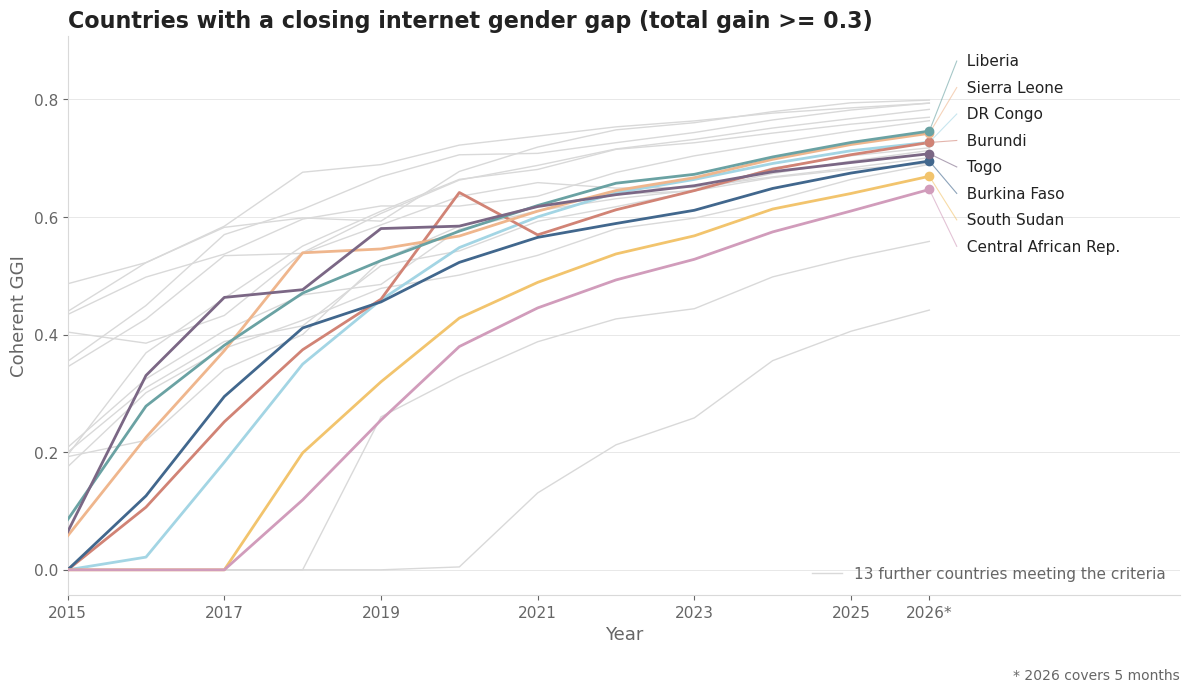

In [6]:
wide_i, sum_i = country_panel(annual, measure('internet'))

closing = sum_i.index[sum_i['total_gain'] >= 0.3].tolist()
print(f'{len(closing)} countries')
trend_plot(wide_i, sum_i, closing,
           'Countries with a closing internet gender gap (total gain >= 0.3)',
           'internet_coherent_closing.png');

## Internet — proportionally large gains

`proportional_gain > 0.25`.

40 countries


  internet_coherent_closing_proportional.png  (8 labelled, 32 context)


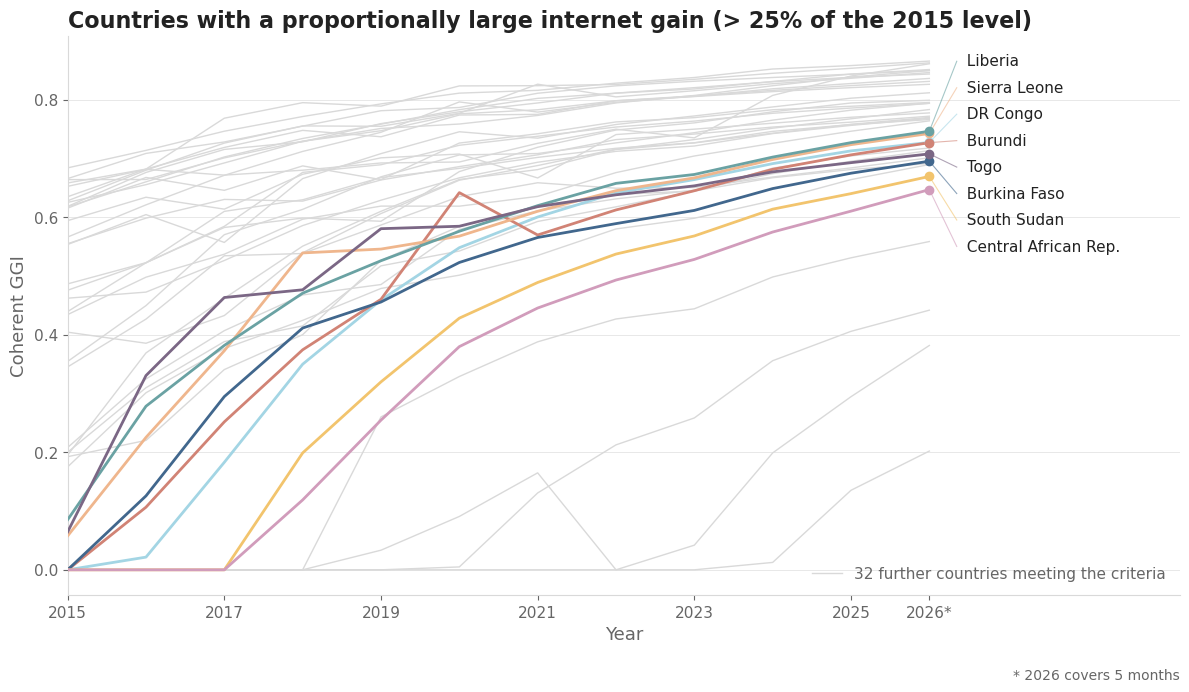

In [7]:
closing2 = sum_i.index[sum_i['proportional_gain'] > 0.25].tolist()
print(f'{len(closing2)} countries')
trend_plot(wide_i, sum_i, closing2,
           'Countries with a proportionally large internet gain (> 25% of the 2015 level)',
           'internet_coherent_closing_proportional.png');

## Internet — case studies

The four countries the `.qmd` annotates: Afghanistan, Eritrea, Djibouti, Turkmenistan. The original
carried hand-placed event annotations (social-media shutdown, regime change, intensified internet
control); those coordinates were tuned to the direct measure's scale and would sit wrong here, so
they are left out rather than moved to fit.

  internet_coherent_case_studies.png  (4 labelled, 0 context)


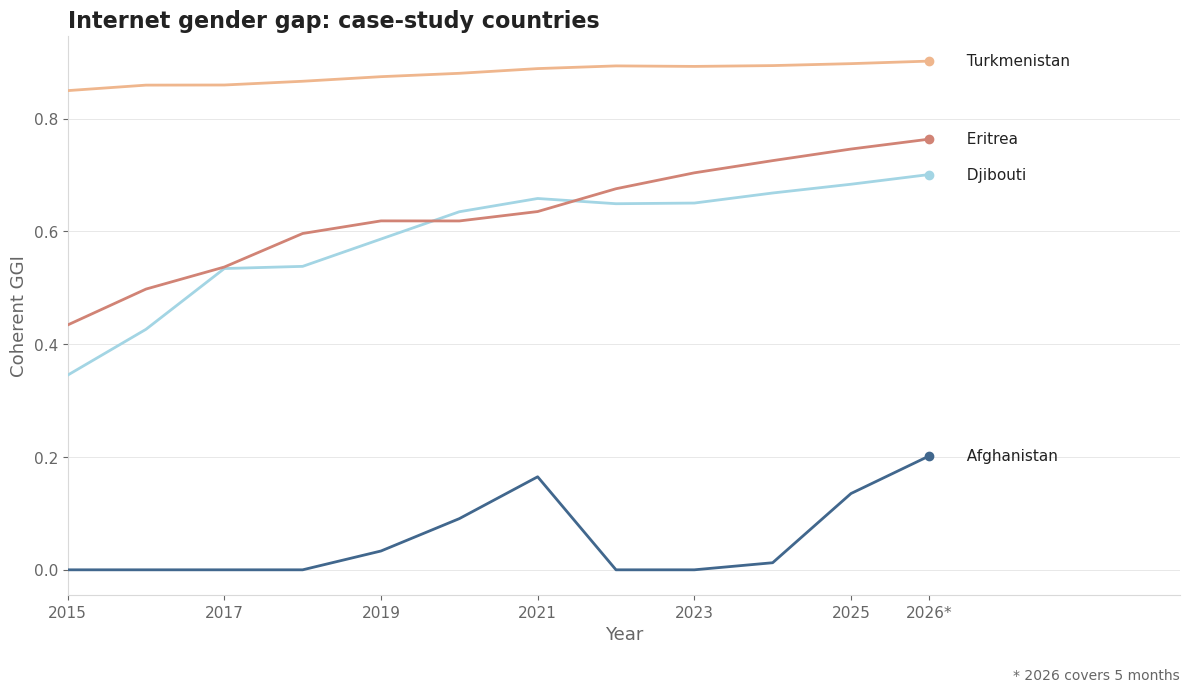

In [8]:
case_studies = [c for c in ['AFG', 'ERI', 'DJI', 'TKM'] if c in wide_i.index]
trend_plot(wide_i, sum_i, case_studies,
           'Internet gender gap: case-study countries',
           'internet_coherent_case_studies.png');

## Internet — stagnant gaps

`total_gain <= 0.1` and `mean_pred < 0.8`, excluding Yemen.

**This figure is empty under the coherent measure.** See the diagnostic below — it is a substantive
result, not a failure.

In [9]:
def stagnant(summary, wide):
    # the .qmd excluded Yemen inline; that now happens upstream in 13_coherent_ggi.py for every
    # output, via params.excluded_countries (D21), so no per-figure filter is needed
    keep = (summary['total_gain'] <= 0.1) & (summary['mean_pred'] < 0.8)
    return list(summary.index[keep])


stagnant_i = stagnant(sum_i, wide_i)
trend_plot(wide_i, sum_i, stagnant_i,
           'Countries with a stagnant internet gender gap',
           'internet_coherent_stagnant.png');

# why the set empties: compare against the direct measure on the same filter
wide_d, sum_d = country_panel(annual, measure('internet', 'direct'))
stagnant_direct = stagnant(sum_d, wide_d)

diag = pd.DataFrame({
    'gain_direct': sum_d.loc[stagnant_direct, 'total_gain'],
    'mean_direct': sum_d.loc[stagnant_direct, 'mean_pred'],
    'gain_coherent': sum_i.loc[stagnant_direct, 'total_gain'],
    'mean_coherent': sum_i.loc[stagnant_direct, 'mean_pred'],
}).round(3)
diag['excluded_because'] = np.where(diag['gain_coherent'] > 0.1, 'gain > 0.1',
                             np.where(diag['mean_coherent'] >= 0.8, 'mean >= 0.8', '-'))
print(f'\ndirect measure selects {len(stagnant_direct)}, coherent selects {len(stagnant_i)}:')
diag

  [skip] internet_coherent_stagnant.png: no countries meet the criteria

direct measure selects 7, coherent selects 0:


,gain_direct,mean_direct,gain_coherent,mean_coherent,excluded_because
gid_0,,,,,
AFG,0.041,0.202,0.135,0.053,gain > 0.1
DJI,0.088,0.544,0.339,0.590,gain > 0.1
ERI,0.057,0.521,0.312,0.629,gain > 0.1
KIR,0.001,0.779,-0.022,0.841,mean >= 0.8
TKM,-0.081,0.718,0.048,0.880,mean >= 0.8
UGA,0.032,0.590,0.176,0.699,gain > 0.1
UZB,0.072,0.621,0.017,0.870,mean >= 0.8


## Internet — best and worst movers

`total_gain` at its minimum and maximum.

{'Guam': np.float64(-0.04), 'DR Congo': np.float64(0.713)}


  internet_coherent_best_worst.png  (2 labelled, 0 context)


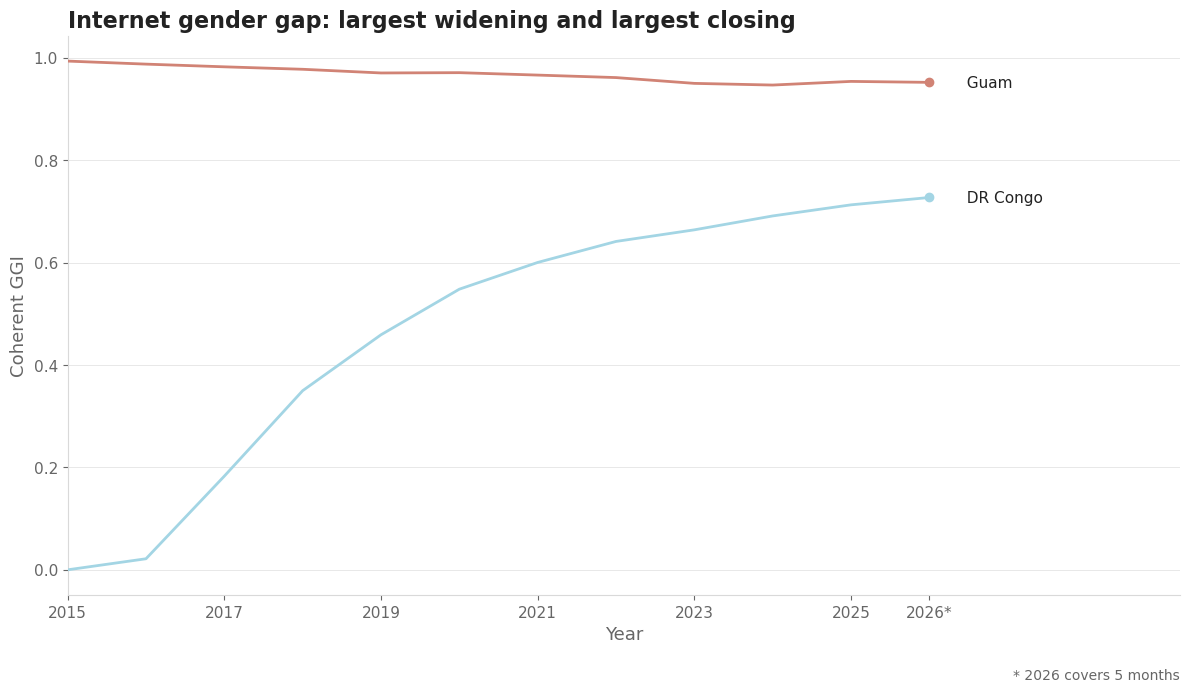

In [10]:
extremes = [sum_i['total_gain'].idxmin(), sum_i['total_gain'].idxmax()]
print({sum_i.loc[c, 'country']: round(sum_i.loc[c, 'total_gain'], 3) for c in extremes})
trend_plot(wide_i, sum_i, extremes,
           'Internet gender gap: largest widening and largest closing',
           'internet_coherent_best_worst.png');

## Mobile

Same three figures, with the `.qmd`'s mobile threshold (`total_gain >= 0.2`).

  mobile_coherent_closing.png  (3 labelled, 0 context)


  mobile_coherent_case_studies.png  (4 labelled, 0 context)


  mobile_coherent_stagnant.png  (5 labelled, 0 context)


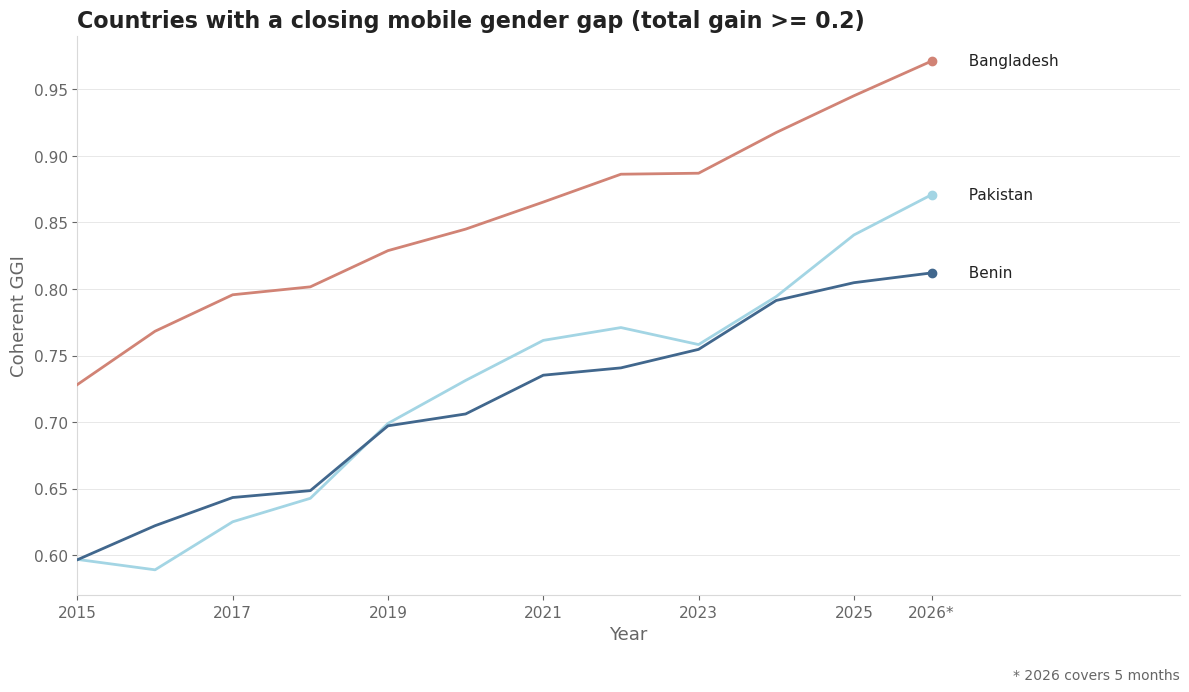

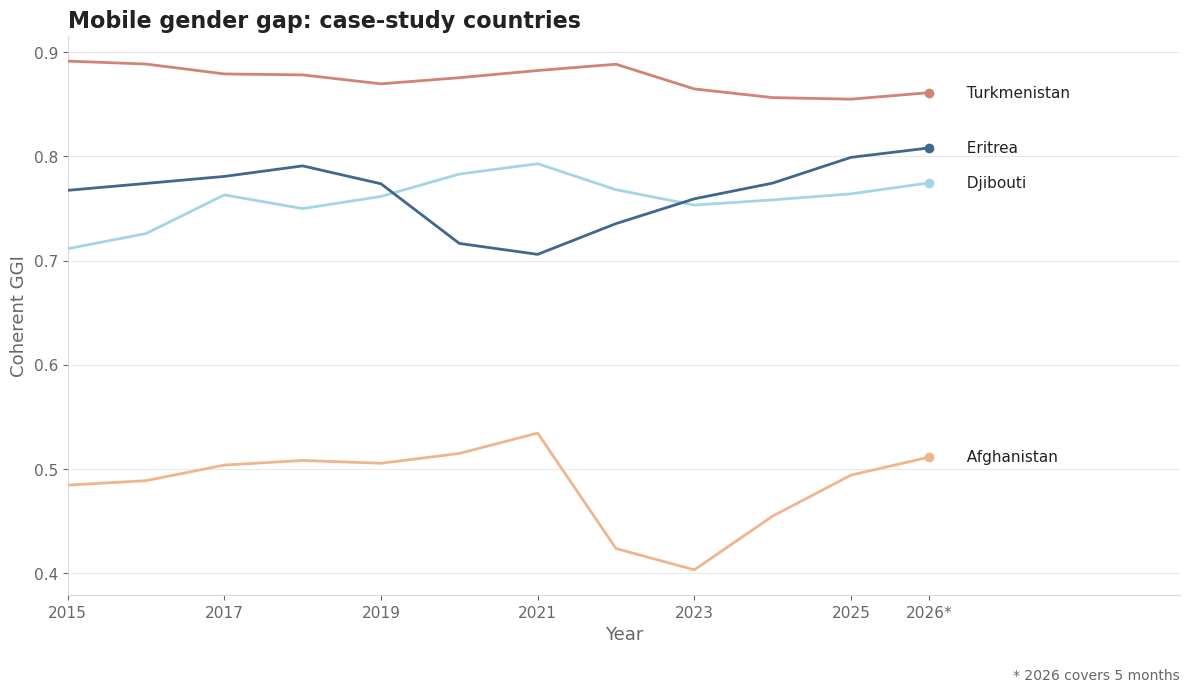

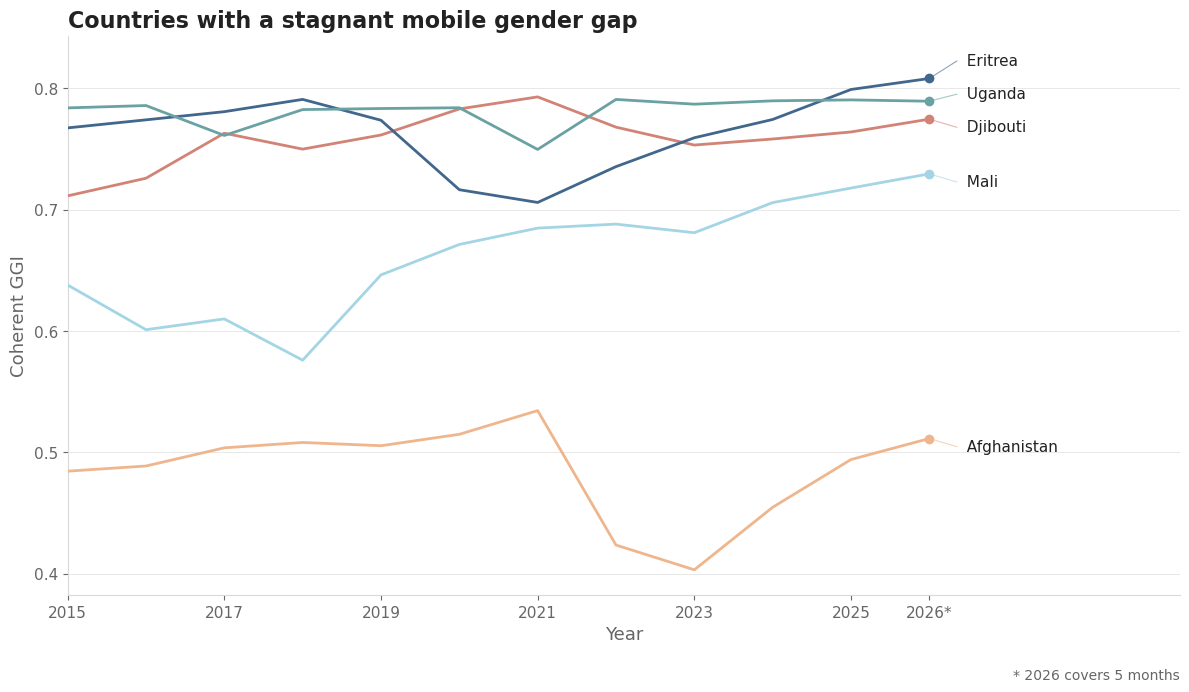

In [11]:
wide_m, sum_m = country_panel(annual, measure('mobile'))

trend_plot(wide_m, sum_m, sum_m.index[sum_m['total_gain'] >= 0.2].tolist(),
           'Countries with a closing mobile gender gap (total gain >= 0.2)',
           'mobile_coherent_closing.png')

trend_plot(wide_m, sum_m, [c for c in ['AFG', 'ERI', 'DJI', 'TKM'] if c in wide_m.index],
           'Mobile gender gap: case-study countries',
           'mobile_coherent_case_studies.png')

trend_plot(wide_m, sum_m, stagnant(sum_m, wide_m),
           'Countries with a stagnant mobile gender gap',
           'mobile_coherent_stagnant.png');

## Regional trends

One panel per World Bank region. Each panel carries every country in the region as a thin line, the
regional median with a ±1 standard-deviation band, and the top and bottom country at the final year
labelled by ISO3 code.

Country identity is deliberately *not* colour-coded — with up to 55 countries in a region, colour
could not carry identity. The distribution is the message; the two labelled extremes give it scale.

  internet_coherent_regional_facets.png  (7 regions)


  mobile_coherent_regional_facets.png  (7 regions)


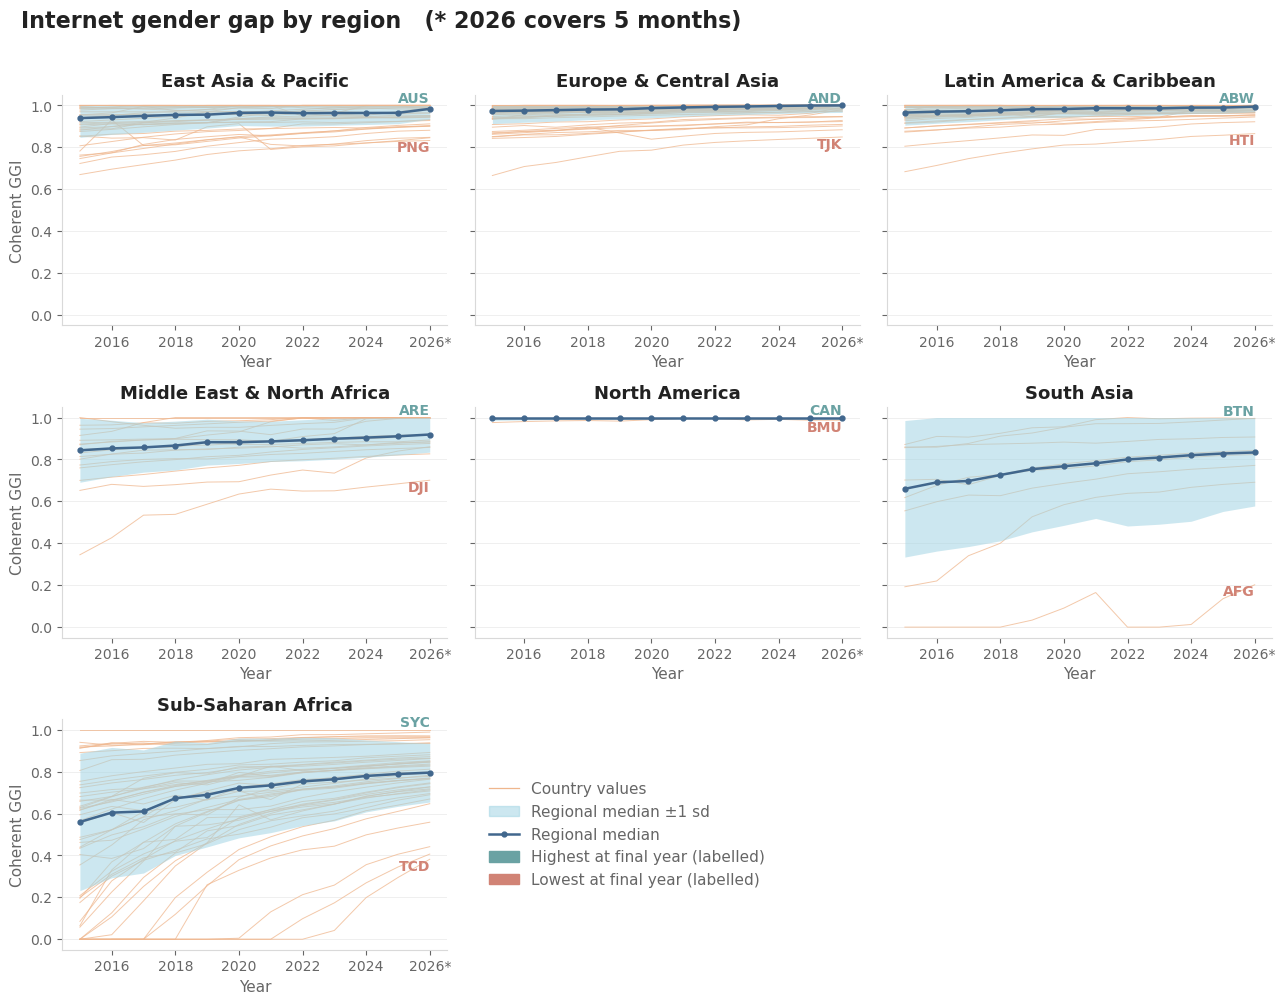

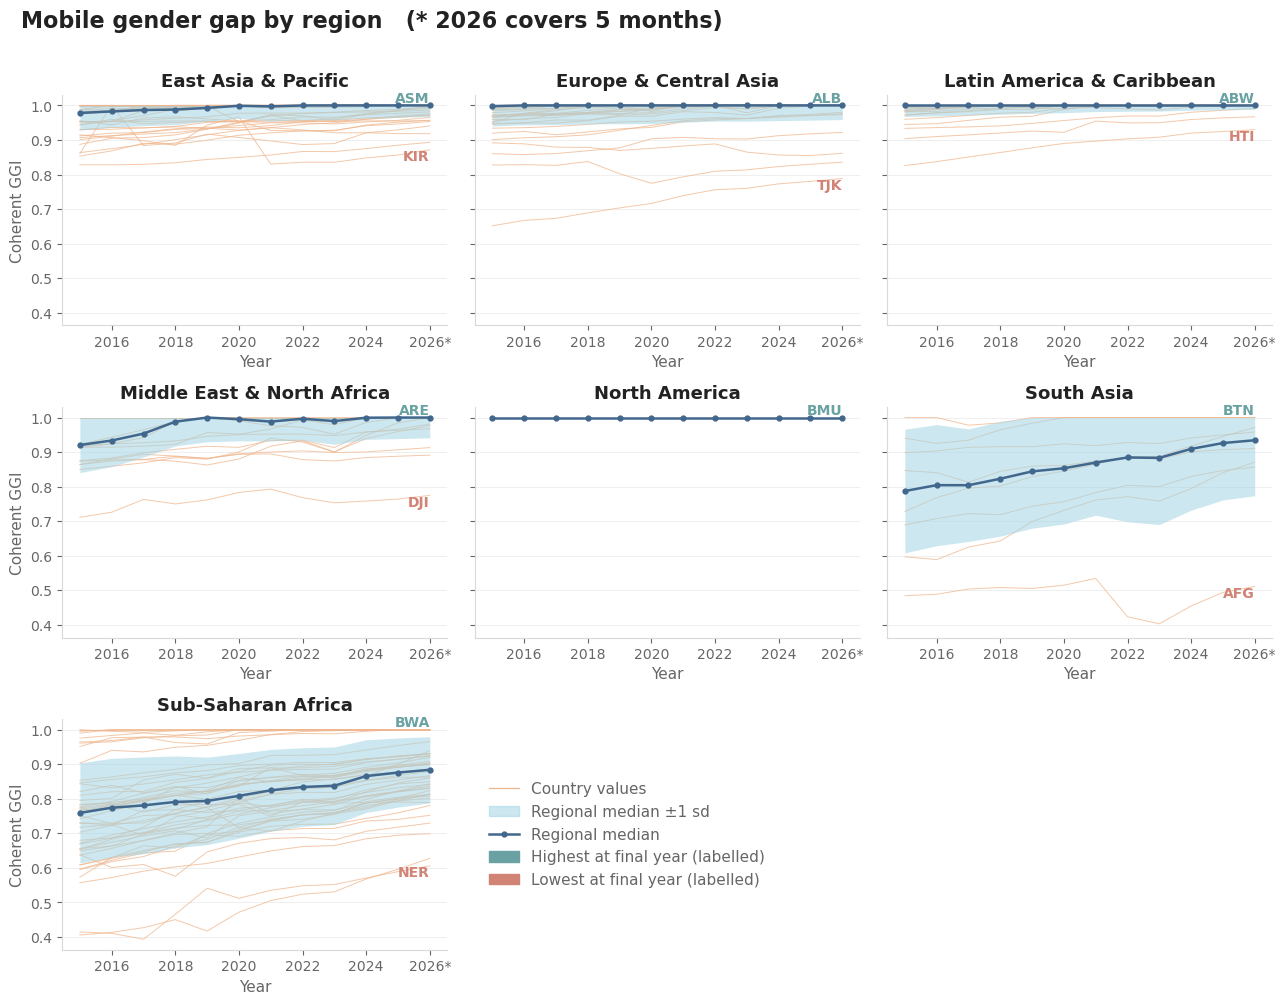

In [12]:
def regional_facets(indicator, filename):
    """
    small multiples: country spread, regional median and +/-1 sd, extremes labelled

    Colour here is semantic rather than categorical — one hue for the country spread, one for the
    median and its band, and a top/bottom pair for the extremes. The extreme labels are also
    separated by position (highest sits at the top of the panel, lowest at the bottom) and by their
    ISO3 code, so the good/bad reading never rests on hue alone.
    """
    col = measure(indicator)
    regions = sorted(annual['region'].dropna().unique())
    ncols = 3
    nrows = int(np.ceil((len(regions) + 1) / ncols))   # +1 leaves a slot for the legend

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.4 * nrows), sharey=True)
    axes = axes.flatten()

    spread_c = params.colors['peach']
    band_c   = params.colors['light_blue']
    median_c = params.colors['blue']
    top_c    = params.colors['teal']
    bottom_c = params.colors['red']

    for ax, region in zip(axes, regions):
        block = annual[annual['region'] == region]
        wide = block.pivot_table(index='gid_0', columns='year', values=col)
        years = wide.columns.tolist()

        for iso in wide.index:
            ax.plot(years, wide.loc[iso], color=spread_c, linewidth=0.7, alpha=0.75, zorder=1)

        med, sd = wide.median(axis=0), wide.std(axis=0)
        # the parity-capped GGI lives in [0, 1]; a band drawn outside that is not a possible value
        lower = (med - sd).clip(lower=0.0)
        upper = (med + sd).clip(upper=params.COHERENT_GGI['parity_cap'])
        ax.fill_between(years, lower, upper, color=band_c, alpha=0.55, zorder=2, linewidth=0)
        ax.plot(years, med, color=median_c, linewidth=1.8, zorder=3)
        ax.plot(years, med, 'o', color=median_c, markersize=3.5, zorder=4)

        # label the extremes, unless the region has no spread left to distinguish them — where every
        # country is saturated at parity, idxmax and idxmin return the same row and one label is honest
        final = wide[TREND_END].dropna()
        if len(final):
            extremes = [(final.idxmax(), top_c, 'bottom')]
            if final.idxmin() != final.idxmax() and not np.isclose(final.min(), final.max()):
                extremes.append((final.idxmin(), bottom_c, 'top'))
            for iso, colour, va in extremes:
                ax.annotate(iso, (TREND_END, wide.loc[iso, TREND_END]),
                            color=colour, fontsize=STYLE['tick_fs'] - 1, fontweight='bold',
                            ha='right', va=va, zorder=6)

        ax.set_title(region, fontsize=STYLE['label_fs'], color=INK, fontweight='bold')
        ax.grid(axis='y', color=GRID, linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        for spine in ['left', 'bottom']:
            ax.spines[spine].set_color(GRID)
        ax.tick_params(labelsize=STYLE['tick_fs'] - 1, colors=MUTED)
        ticks = [y for y in range(TREND_START + 1, TREND_END + 1, 2)]
        ax.set_xticks(ticks)
        ax.set_xticklabels([f'{y}*' if FINAL_YEAR_PARTIAL and y == TREND_END else str(y)
                            for y in ticks])

    # legend occupies the first unused panel
    legend_ax = axes[len(regions)]
    legend_ax.axis('off')
    handles = [
        plt.Line2D([], [], color=spread_c, linewidth=0.9, label='Country values'),
        mpatches.Patch(color=band_c, alpha=0.55, label='Regional median ±1 sd'),
        plt.Line2D([], [], color=median_c, linewidth=1.8, marker='o', markersize=3.5,
                   label='Regional median'),
        mpatches.Patch(color=top_c, label='Highest at final year (labelled)'),
        mpatches.Patch(color=bottom_c, label='Lowest at final year (labelled)'),
    ]
    legend_ax.legend(handles=handles, frameon=False, loc='center left',
                     fontsize=STYLE['tick_fs'], labelcolor=MUTED)

    for ax in axes[len(regions) + 1:]:
        ax.axis('off')

    for ax in axes[:len(regions)]:
        if not ax.get_subplotspec().is_last_row() and ax.get_subplotspec().rowspan.start < nrows - 1:
            pass
        ax.set_xlabel('Year', fontsize=STYLE['tick_fs'], color=MUTED)
    for r in range(nrows):
        axes[r * ncols].set_ylabel('Coherent GGI', fontsize=STYLE['tick_fs'], color=MUTED)

    note = f'{indicator.capitalize()} gender gap by region'
    if FINAL_YEAR_PARTIAL:
        note += f'   (* {TREND_END} covers {FINAL_YEAR_MONTHS} months)'
    fig.suptitle(note, fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(FIGDIR / filename, dpi=STYLE['dpi'], bbox_inches='tight')
    print(f'  {filename}  ({len(regions)} regions)')
    return fig


regional_facets('internet', 'internet_coherent_regional_facets.png')
regional_facets('mobile', 'mobile_coherent_regional_facets.png');

## Coherent vs direct, side by side

The comparison a reviewer will ask for: same countries, both measures.

  internet_coherent_vs_direct.png


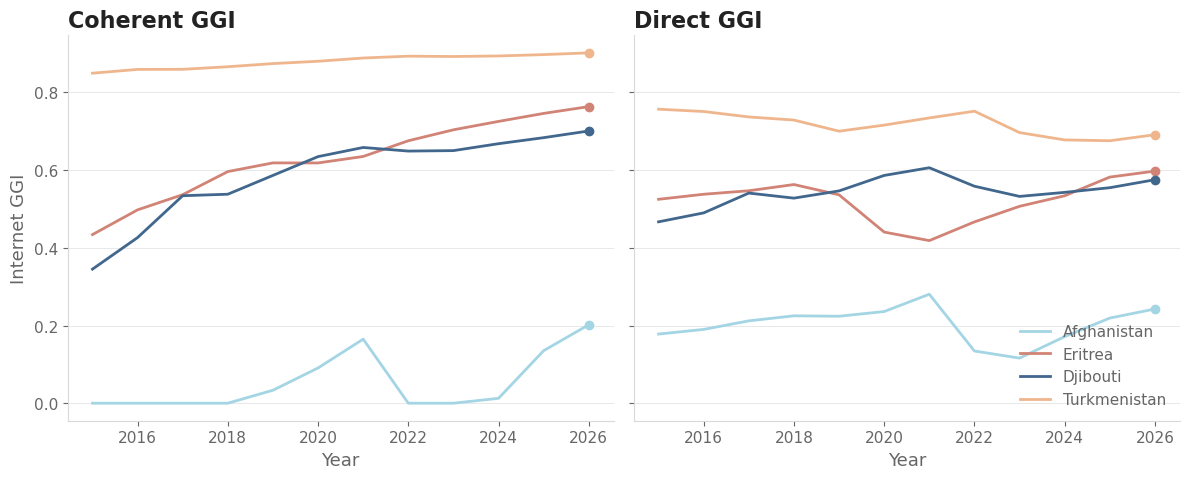

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(STYLE['figsize'][0], STYLE['figsize'][1] * 0.7), sharey=True)

for ax, (kind, panel, summ) in zip(axes, [('Coherent', wide_i, sum_i), ('Direct', wide_d, sum_d)]):
    for i, iso in enumerate(case_studies):
        colour = PALETTE[i % len(PALETTE)]
        ax.plot(panel.columns, panel.loc[iso], color=colour, linewidth=2,
                label=summ.loc[iso, 'country'])
        ax.plot(panel.columns[-1], panel.loc[iso].iloc[-1], 'o', color=colour, markersize=6)
    ax.set_title(f'{kind} GGI', fontsize=STYLE['title_fs'], color=INK, loc='left', fontweight='bold')
    ax.set_xlabel('Year', fontsize=STYLE['label_fs'], color=MUTED)
    ax.tick_params(labelsize=STYLE['tick_fs'], colors=MUTED)
    ax.grid(axis='y', color=GRID, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(GRID)

axes[0].set_ylabel('Internet GGI', fontsize=STYLE['label_fs'], color=MUTED)
axes[1].legend(frameon=False, fontsize=STYLE['tick_fs'], loc='lower right', labelcolor=MUTED)
fig.tight_layout()
fig.savefig(FIGDIR / 'internet_coherent_vs_direct.png', dpi=STYLE['dpi'], bbox_inches='tight')
print('  internet_coherent_vs_direct.png')

## Notes

### The floor artefact — read the case-study figure with this in mind

`internet_coherent_vs_direct.png` shows Afghanistan's coherent GGI sitting at exactly **0** for
2015–2018, against 0.18–0.23 on the direct measure. That is the *lower* bound doing the same thing
the ceiling does at the top: predicted female internet is clipped to 0 while male runs 0.20–0.26, so
the ratio is 0 — total exclusion — by construction.

This affects **246 country-months across 11 countries** (AFG, BDI, BFA, CAF, COD, MLI, NER, SOM,
SSD, TCD, YEM) — all low-income, and precisely the group the widening-gap narrative is about. The
coherent measure is more sensitive to the level model's floor than the direct measure is, and a
reported GGI of 0 should be read as "female adoption below the model's resolution", not as a
measured value. `{ind}_flag_level_at_bound` marks these rows.

The same figure also shows Turkmenistan moving in **opposite directions** under the two measures
(coherent 0.85 → 0.89 rising; direct 0.76 → 0.67 falling). The choice of measure is not cosmetic for
the case-study countries.

- Figures write to `outputs/fig/coherent_ggi/`; the originals in `outputs/fig/trend_analysis_PAA/`
  are left untouched for comparison.
- The four `fb_*.png` case studies in `trend.qmd` plot Facebook MAU and the 18+ audience ratio, not
  the GGI, so they are unaffected by the measure change and are not reproduced here.
- The palette is the project's own eight colours, reordered for discriminability (`params.plot_color_order`).
  Two validator checks still fail on the colours themselves — three sit outside the lightness band
  and seven below the chroma floor, and six fall under 3:1 contrast against the surface. Direct
  labelling on every highlighted series is the required relief; the underlying values are in
  `outputs/tables/` for anyone who cannot resolve the hues.